# This notebook for understanding processed data after preprocessing and cleaning

In [1]:
# Importing important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sys
import os
import sys
from pathlib import Path


In [2]:

# 1. Get the current working directory
current_dir = Path.cwd()
project_root = current_dir

# 2. Traverse upwards until we find the root directory (which contains 'src')
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

# 3. Add the project root to the system path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root successfully set to: {project_root}")


Project root successfully set to: d:\CreditRisk-ML\CreditRisk-ML


In [3]:
import time
from src.data.data_fetching.load_data import processed_train_path

print("Path used by load_data.py:", processed_train_path)
print("File exists:", processed_train_path.exists())
print("Last modified:", time.ctime(processed_train_path.stat().st_mtime))
print("Current time:", time.ctime(time.time()))

Path used by load_data.py: D:\CreditRisk-ML\CreditRisk-ML\data\processed\processed_train.csv
File exists: True
Last modified: Tue Sep  1 21:41:01 2026
Current time: Tue Sep  1 21:41:22 2026


In [4]:
from src.data.data_fetching.load_data import load_processed_data
processed_train_data, processed_test_data = load_processed_data()
processed_train_data = processed_train_data.rename(columns={'Unnamed: 0': 'Id'})

cols_to_check = [col for col in processed_train_data.columns if col.lower() != 'id']
print("Duplicates:", processed_train_data[cols_to_check].duplicated().sum())
print("Shape:", processed_train_data.shape)

Loading training data from: D:\CreditRisk-ML\CreditRisk-ML\data\processed\processed_train.csv
Loading testing data from: D:\CreditRisk-ML\CreditRisk-ML\data\processed\processed_test.csv
Data loaded successfully!

Duplicates: 0
Shape: (145698, 13)


In [5]:
# loading processed data
from src.data.data_fetching.load_data import load_processed_data

processed_train_data,processed_test_data = load_processed_data()
if processed_train_data is not None:
    print("\n--- Training Data successfully loaded into Notebook ---")
    processed_train_data = processed_train_data.rename(columns={'Unnamed: 0': 'Id'})
    print(f"Train shape: {processed_train_data.shape}")
    display(processed_train_data.head())

if processed_test_data is not None:
    processed_test_data = processed_test_data.rename(columns={'Unnamed: 0': 'Id'})
    print("\n--- Test Data successfully loaded into Notebook ---")
    print(f"Test shape: {processed_test_data.shape}")
    display(processed_test_data.head())

Loading training data from: D:\CreditRisk-ML\CreditRisk-ML\data\processed\processed_train.csv
Loading testing data from: D:\CreditRisk-ML\CreditRisk-ML\data\processed\processed_test.csv
Data loaded successfully!


--- Training Data successfully loaded into Notebook ---
Train shape: (145698, 13)


,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebt,NonRealEstateLoans
0,1,1,0.766127,45.0,2,9120.0,13.0,0,6.0,0,2.0,7323.197016,7.0
1,2,0,0.957151,40.0,0,2600.0,4.0,0,0.0,0,1.0,316.878123,4.0
2,3,0,0.658180,38.0,1,3042.0,2.0,1,0.0,0,0.0,258.914887,2.0
3,4,0,0.233810,30.0,0,3300.0,5.0,0,0.0,0,0.0,118.963951,5.0
4,5,0,0.907239,49.0,1,63588.0,7.0,0,1.0,0,0.0,1584.975094,6.0



--- Test Data successfully loaded into Notebook ---
Test shape: (101503, 13)


,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebt,NonRealEstateLoans
0,1,NaN,0.885519,43.0,0,5700.0,4.0,0,0.0,0,0.0,1011.822487,4.0
1,2,NaN,0.463295,57.0,0,9141.0,15.0,0,4.0,0,2.0,4819.472759,11.0
2,3,NaN,0.043275,59.0,0,5083.0,12.0,0,1.0,0,2.0,3495.312354,11.0
3,4,NaN,0.280308,38.0,1,3200.0,7.0,0,2.0,0,0.0,2963.074038,5.0
4,5,NaN,1.000000,27.0,0,3865.0,4.0,0,0.0,0,1.0,76.980082,4.0


## Duplicates

In [6]:
cols_to_check = [col for col in processed_train_data.columns if col.lower() != 'id']
print("Number of duplicates in training data:", processed_train_data[cols_to_check].duplicated().sum())

Number of duplicates in training data: 0


In [7]:
cols_to_check = [col for col in processed_test_data.columns if col.lower() != 'id']
print("Number of duplicates in test data:", processed_test_data[cols_to_check].duplicated().sum())

Number of duplicates in test data: 432


## Missing values

In [8]:
processed_train_data.isna().sum() / len(processed_train_data) * 100

Id                                      0.0
SeriousDlqin2yrs                        0.0
RevolvingUtilizationOfUnsecuredLines    0.0
age                                     0.0
NumberOfTime30-59DaysPastDueNotWorse    0.0
MonthlyIncome                           0.0
NumberOfOpenCreditLinesAndLoans         0.0
NumberOfTimes90DaysLate                 0.0
NumberRealEstateLoansOrLines            0.0
NumberOfTime60-89DaysPastDueNotWorse    0.0
NumberOfDependents                      0.0
MonthlyDebt                             0.0
NonRealEstateLoans                      0.0
dtype: float64

In [9]:
processed_test_data.isna().sum() / len(processed_test_data) * 100

Id                                        0.0
SeriousDlqin2yrs                        100.0
RevolvingUtilizationOfUnsecuredLines      0.0
age                                       0.0
NumberOfTime30-59DaysPastDueNotWorse      0.0
MonthlyIncome                             0.0
NumberOfOpenCreditLinesAndLoans           0.0
NumberOfTimes90DaysLate                   0.0
NumberRealEstateLoansOrLines              0.0
NumberOfTime60-89DaysPastDueNotWorse      0.0
NumberOfDependents                        0.0
MonthlyDebt                               0.0
NonRealEstateLoans                        0.0
dtype: float64

## Data types

In [10]:
processed_train_data.dtypes

Id                                        int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                     float64
NumberOfTime30-59DaysPastDueNotWorse      int64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans         float64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines            float64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
MonthlyDebt                             float64
NonRealEstateLoans                      float64
dtype: object

In [11]:
processed_test_data.dtypes

Id                                        int64
SeriousDlqin2yrs                        float64
RevolvingUtilizationOfUnsecuredLines    float64
age                                     float64
NumberOfTime30-59DaysPastDueNotWorse      int64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans         float64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines            float64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
MonthlyDebt                             float64
NonRealEstateLoans                      float64
dtype: object

In [12]:
# inspect the data types of the columns in the training and test datasets they are the same or not. If they are not the same.
train_dtypes = processed_train_data.dtypes
test_dtypes = processed_test_data.dtypes
if not train_dtypes.equals(test_dtypes):
    print("The data types of the columns in the training and test datasets are not the same.")
    print("Columns with different data types:")
    for col in processed_train_data.columns:
        if col in processed_test_data.columns and processed_train_data[col].dtype != processed_test_data[col].dtype:
            print(f"Column: {col}, Train dtype: {processed_train_data[col].dtype}, Test dtype: {processed_test_data[col].dtype}")

The data types of the columns in the training and test datasets are not the same.
Columns with different data types:
Column: SeriousDlqin2yrs, Train dtype: int64, Test dtype: float64


## Data Information

In [13]:
processed_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145698 entries, 0 to 145697
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    145698 non-null  int64  
 1   SeriousDlqin2yrs                      145698 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  145698 non-null  float64
 3   age                                   145698 non-null  float64
 4   NumberOfTime30-59DaysPastDueNotWorse  145698 non-null  int64  
 5   MonthlyIncome                         145698 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       145698 non-null  float64
 7   NumberOfTimes90DaysLate               145698 non-null  int64  
 8   NumberRealEstateLoansOrLines          145698 non-null  float64
 9   NumberOfTime60-89DaysPastDueNotWorse  145698 non-null  int64  
 10  NumberOfDependents                    145698 non-null  float64
 11  

In [14]:
processed_test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  float64
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   MonthlyIncome                         101503 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       101503 non-null  float64
 7   NumberOfTimes90DaysLate               101503 non-null  int64  
 8   NumberRealEstateLoansOrLines          101503 non-null  float64
 9   NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 10  NumberOfDependents                    101503 non-null  float64
 11  

In [15]:
processed_train_data.describe(include='all')

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebt,NonRealEstateLoans
count,145698.000000,145698.000000,145698.000000,145698.000000,145698.000000,1.456980e+05,145698.000000,145698.000000,145698.000000,145698.000000,145698.000000,145698.000000,145698.000000
mean,74899.115829,0.059273,0.301819,52.509506,0.229420,6.637213e+03,8.548690,0.078320,1.032746,0.056754,0.745027,2063.503899,7.515944
std,43318.058448,0.236136,0.335770,14.692604,0.666652,1.343892e+04,5.139896,0.441715,1.132567,0.303717,1.105271,4212.164938,4.767018
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37379.250000,0.000000,0.028831,42.000000,0.000000,3.818000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,550.890559,4.000000
50%,74848.500000,0.000000,0.143962,52.000000,0.000000,5.416000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,1567.511602,7.000000
75%,112416.750000,0.000000,0.514621,63.000000,0.000000,7.983063e+03,11.000000,0.000000,2.000000,0.000000,1.000000,2814.428188,10.000000
max,150000.000000,1.000000,1.000000,109.000000,13.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000,478450.559160,57.000000


In [16]:
processed_test_data.describe(include='all')

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebt,NonRealEstateLoans
count,101503.000000,0.0,101503.000000,101503.000000,101503.000000,1.015030e+05,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000
mean,50752.000000,NaN,0.320059,52.405436,0.289341,6.723238e+03,8.453514,0.132262,1.013074,0.105888,0.755781,2005.901794,7.440440
std,29301.536524,NaN,0.350568,14.779756,1.148384,3.275883e+04,5.144100,1.030650,1.110253,0.970978,1.127386,3196.752832,4.771762
min,1.000000,NaN,0.000000,21.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25376.500000,NaN,0.030131,41.000000,0.000000,3.786500e+03,5.000000,0.000000,0.000000,0.000000,0.000000,524.900865,4.000000
50%,50752.000000,NaN,0.152586,52.000000,0.000000,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,1549.845020,7.000000
75%,76127.500000,NaN,0.564225,63.000000,0.000000,7.916000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,2786.717657,10.000000
max,101503.000000,NaN,1.000000,104.000000,20.000000,7.727000e+06,85.000000,20.000000,37.000000,20.000000,43.000000,328201.040327,84.000000


## Distribution

--- Plotting Distributions for All Features ---


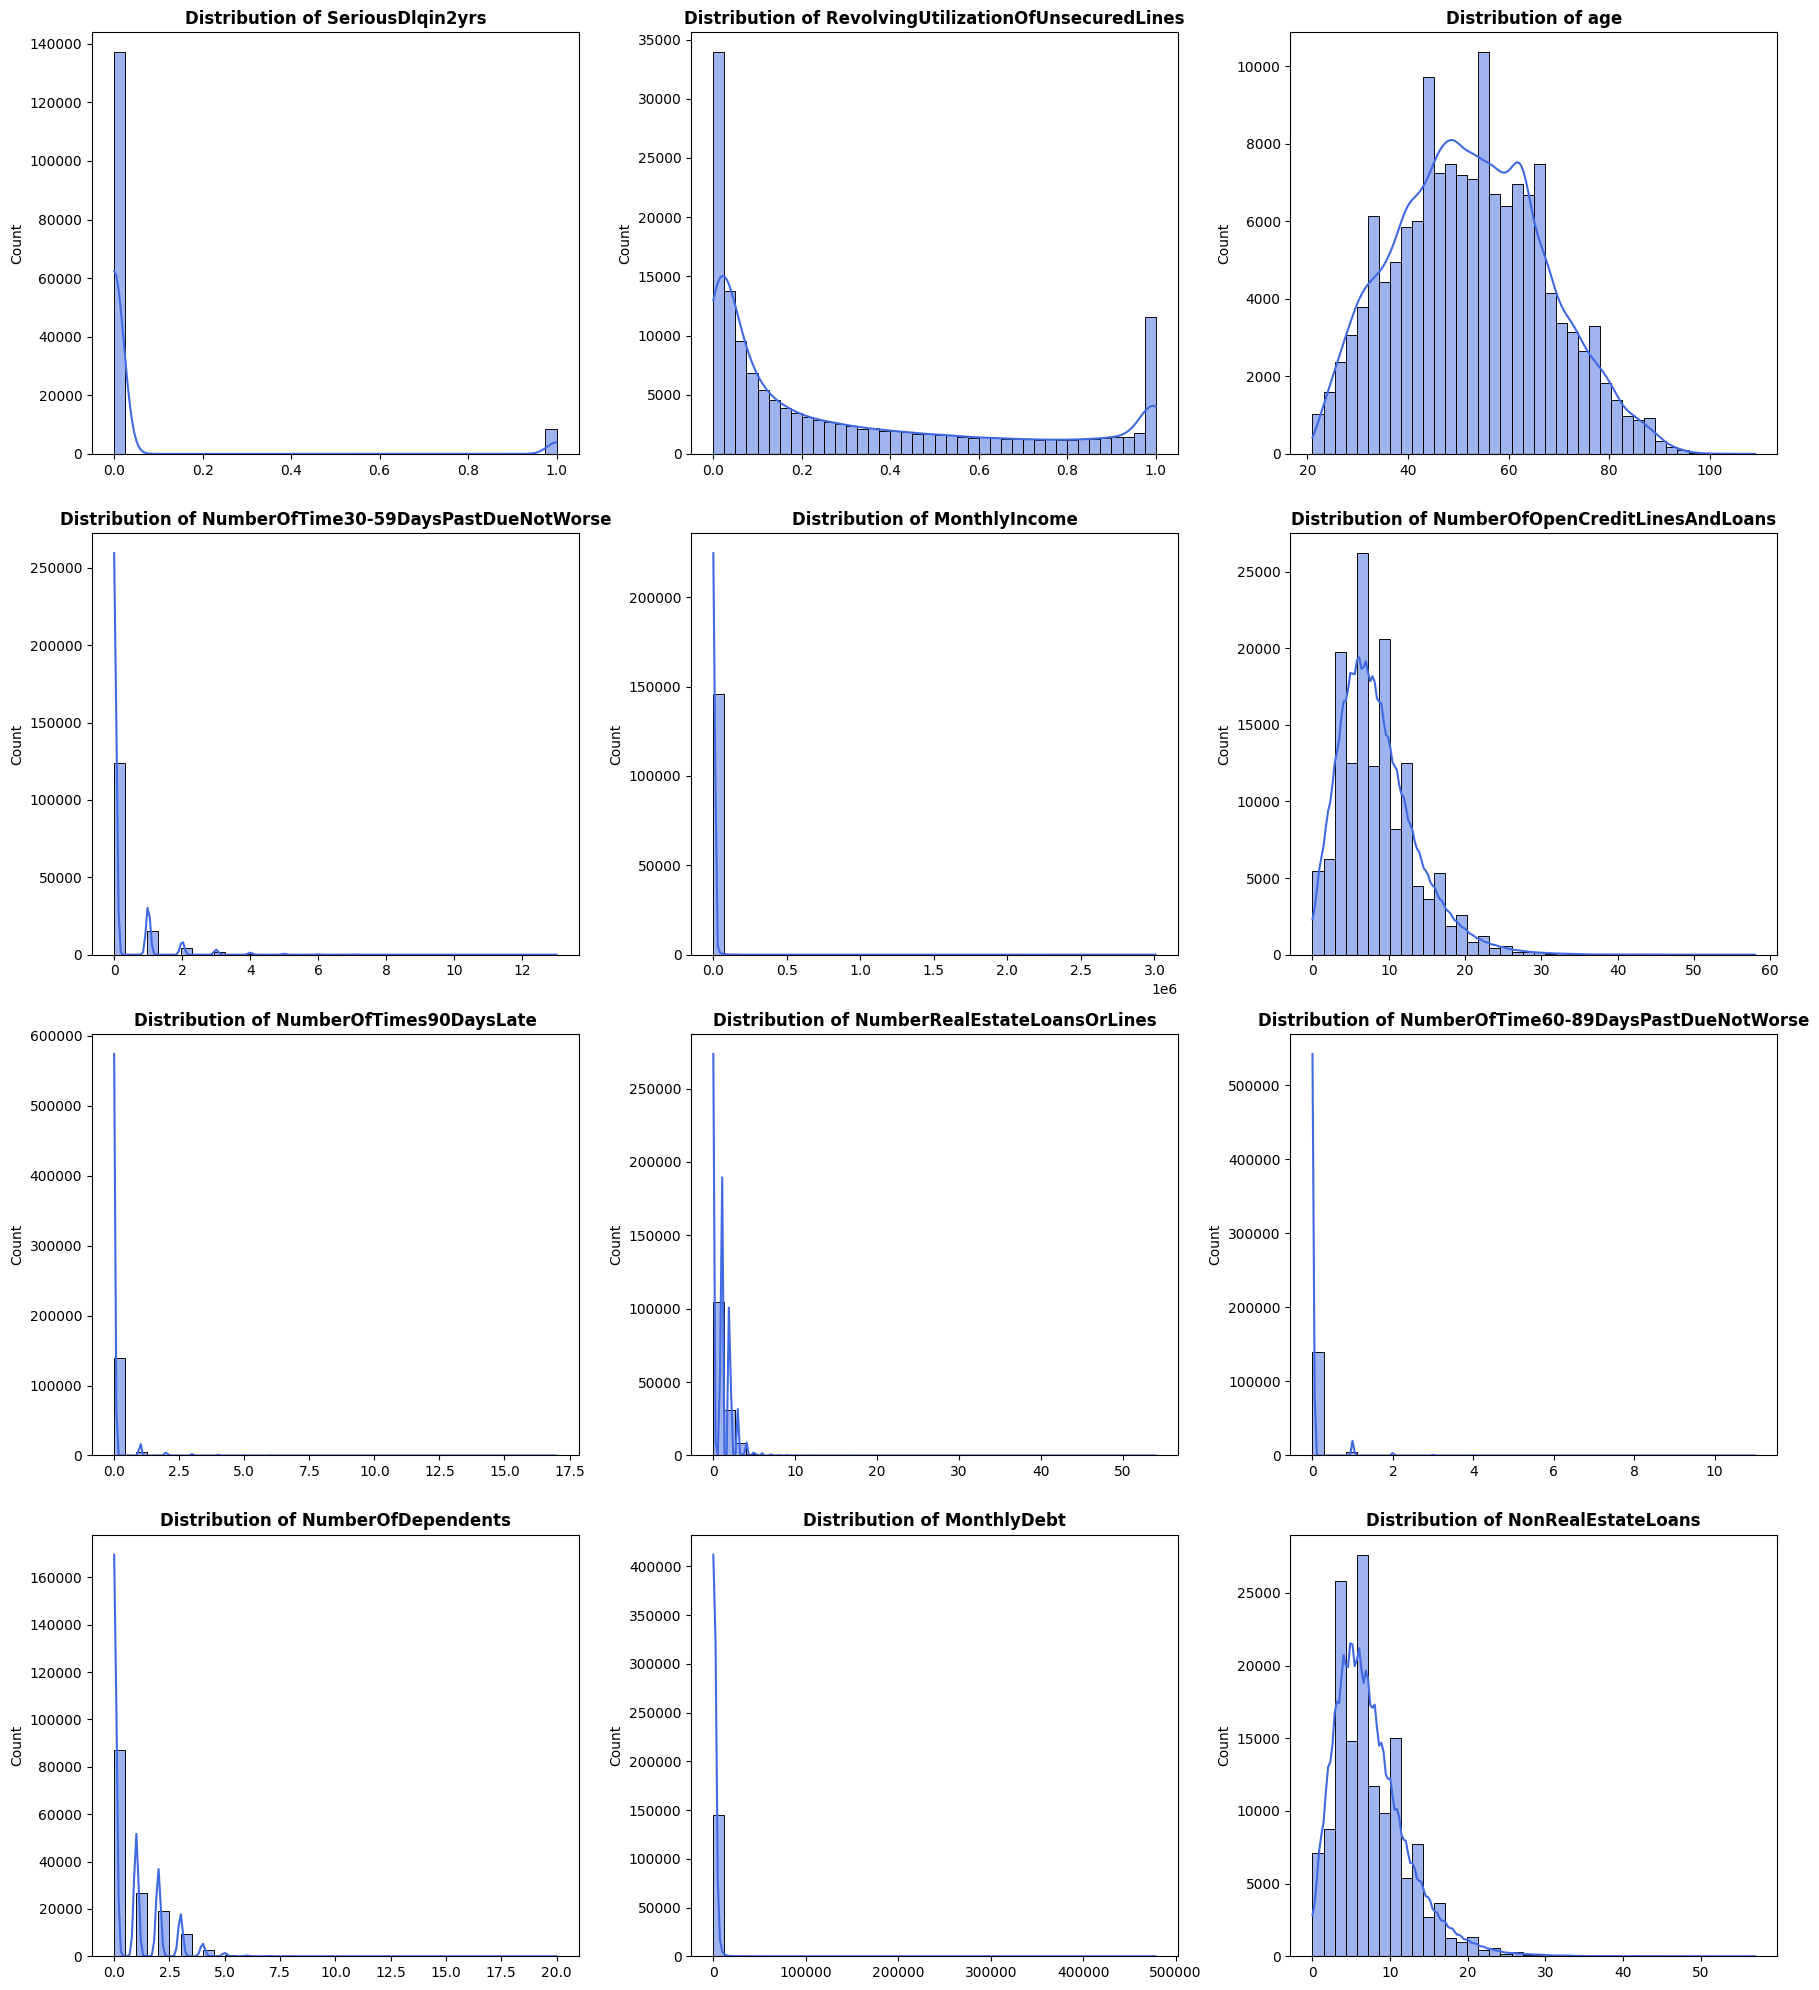

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

print("--- Plotting Distributions for All Features ---")

# 1. Select numerical columns (excluding 'Id')
cols_to_plot = [
    col for col in processed_train_data.columns
    if col.lower() != 'id'
]

# 2. Set number of columns per row
n_cols = 3

# Calculate required number of rows automatically
n_rows = math.ceil(len(cols_to_plot) / n_cols)

# 3. Create figure
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

# 4. Plot distributions
for i, col in enumerate(cols_to_plot):

    sns.histplot(
        processed_train_data[col],
        bins=40,
        kde=True,
        ax=axes[i],
        color='royalblue'
    )

    axes[i].set_title(
        f'Distribution of {col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# 5. Remove unused subplots
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# 6. Display
plt.tight_layout()
plt.show()

--- Plotting Distributions for All Features ---


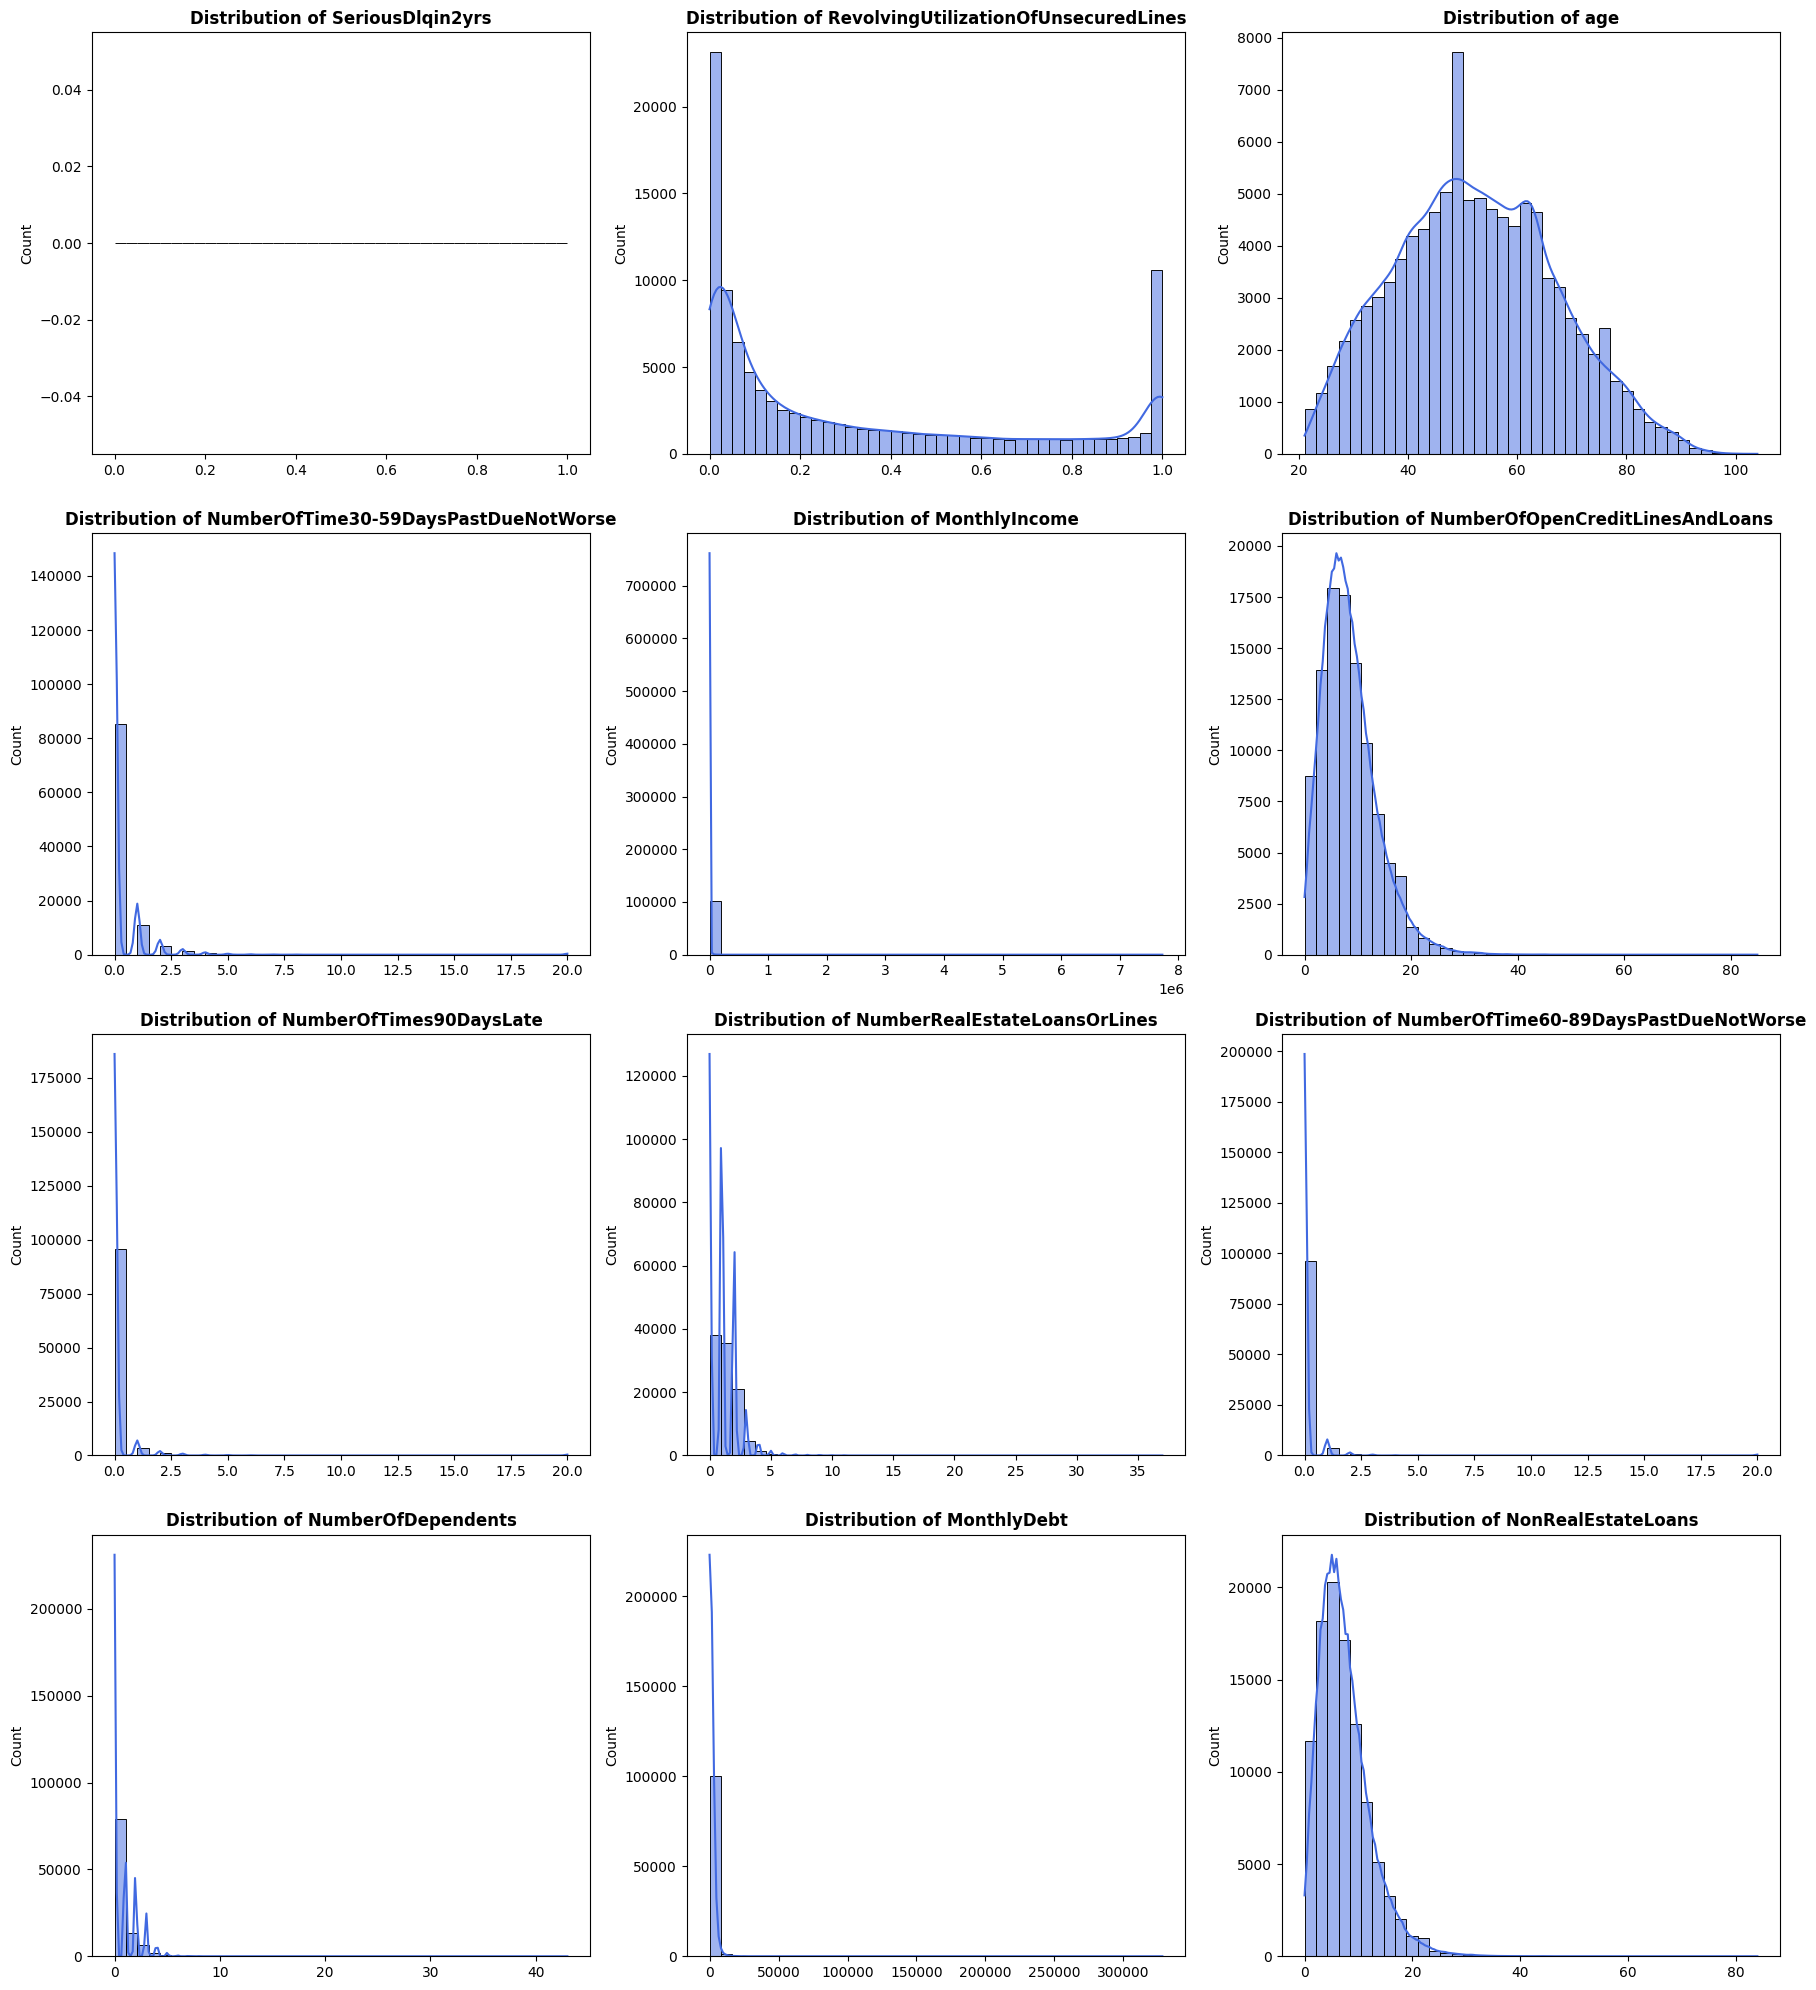

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

print("--- Plotting Distributions for All Features ---")

# 1. Select numerical columns (excluding 'Id')
cols_to_plot = [
    col for col in processed_test_data.columns
    if col.lower() != 'id'
]

# 2. Set number of columns per row
n_cols = 3

# Calculate required number of rows automatically
n_rows = math.ceil(len(cols_to_plot) / n_cols)

# 3. Create figure
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

# 4. Plot distributions
for i, col in enumerate(cols_to_plot):

    sns.histplot(
        processed_test_data[col],
        bins=40,
        kde=True,
        ax=axes[i],
        color='royalblue'
    )

    axes[i].set_title(
        f'Distribution of {col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# 5. Remove unused subplots
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# 6. Display
plt.tight_layout()
plt.show()

## Outliers

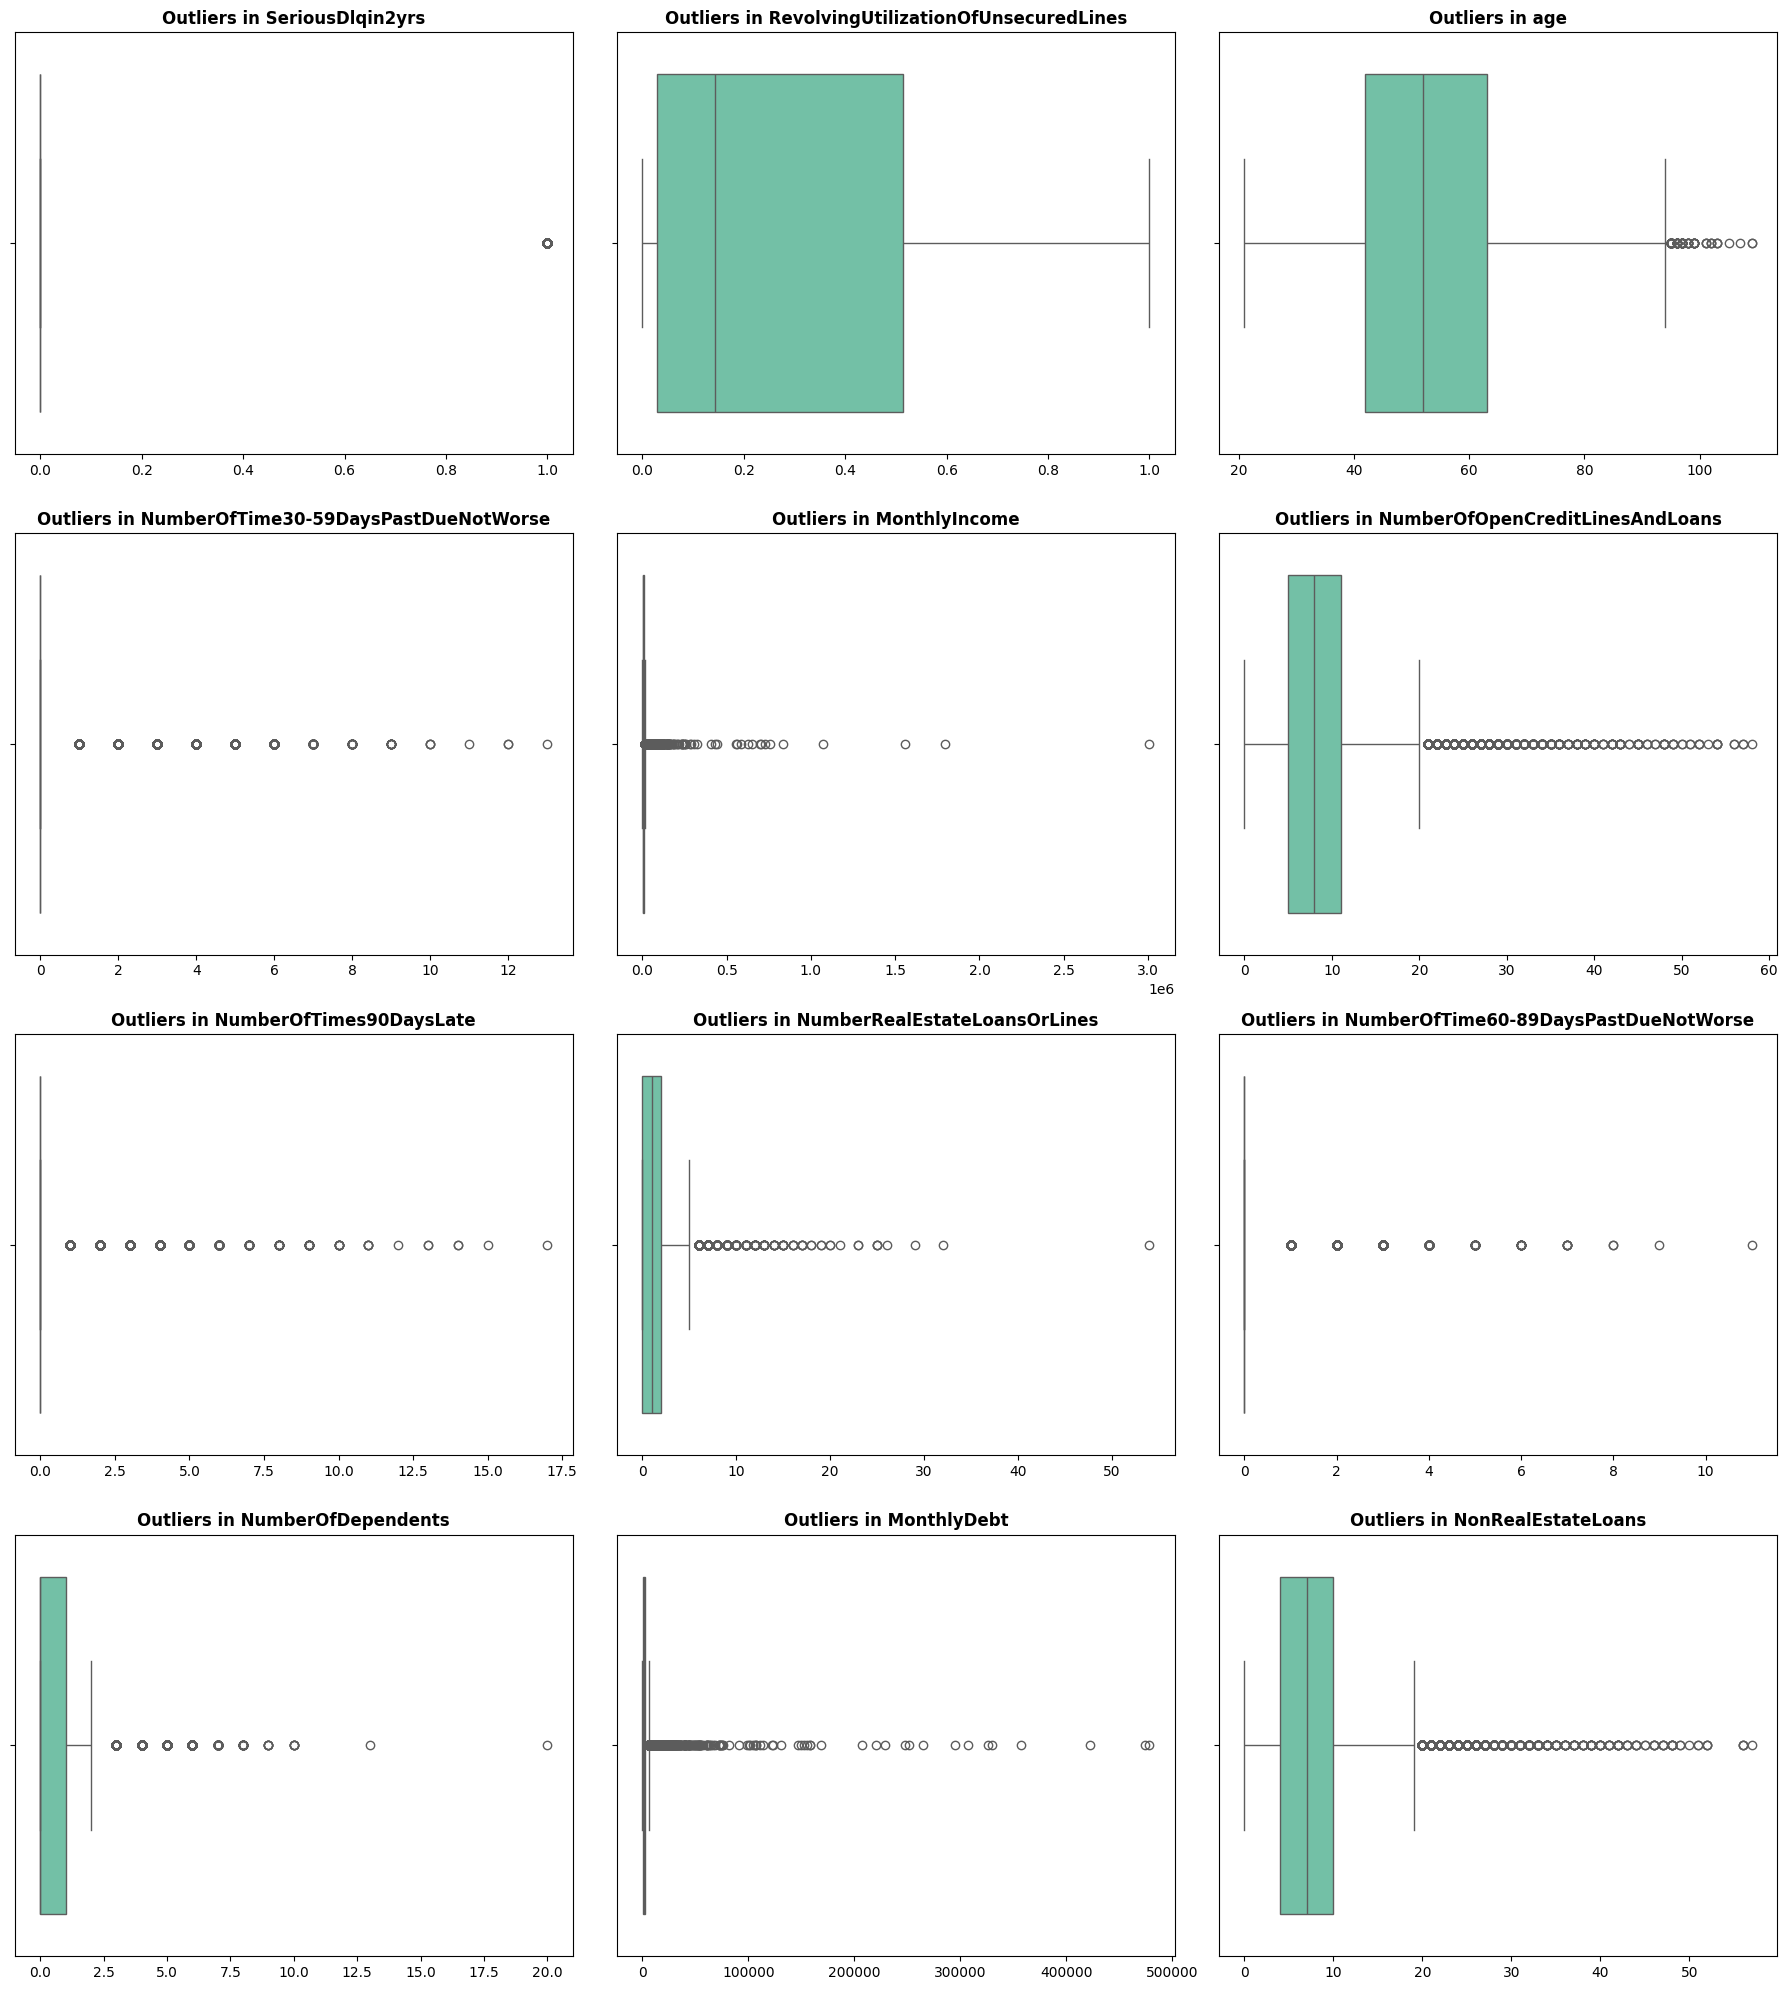

In [19]:
import math

cols_to_plot = [col for col in processed_train_data.columns if col.lower() != 'id']

n = len(cols_to_plot)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=processed_train_data[col], ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

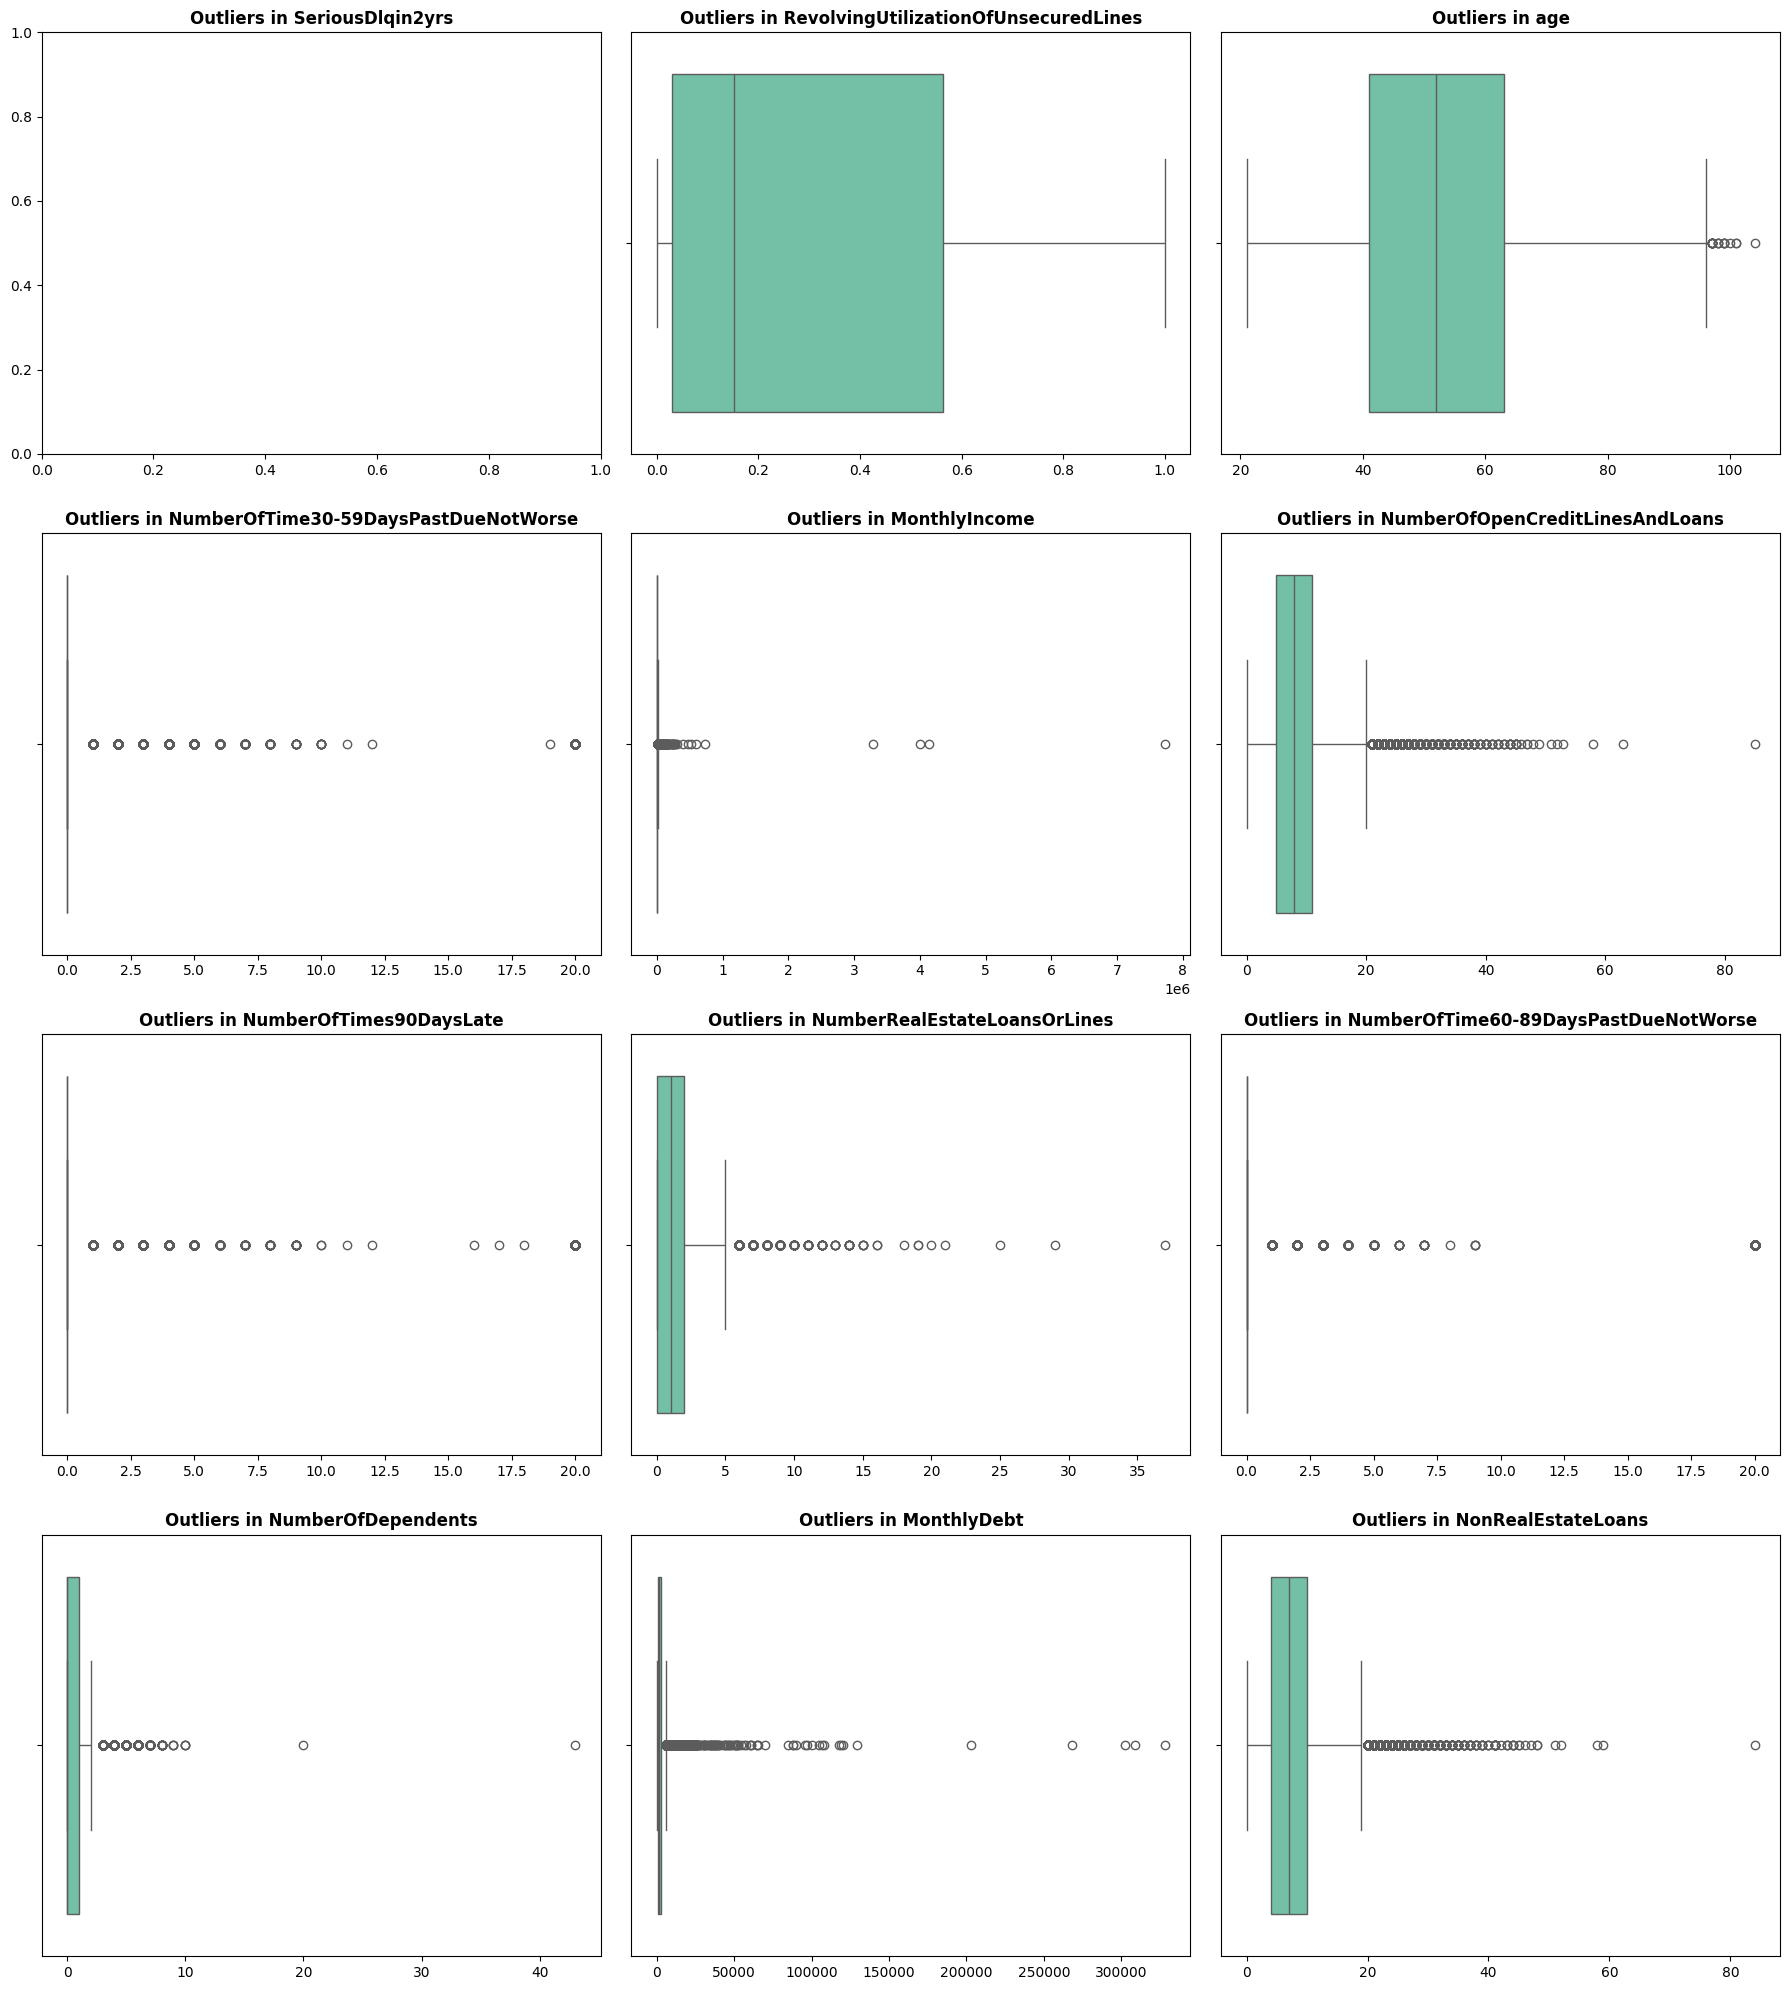

In [20]:
import math

cols_to_plot = [col for col in processed_test_data.columns if col.lower() != 'id']

n = len(cols_to_plot)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=processed_test_data[col].dropna(), ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()